# 01 — Exploratory Data Analysis
## MedIQ — Hospital Patient Analytics & Readmission Predictor
**Goal:** Uncover patient demographics, diagnosis patterns, readmission drivers, and hospital utilization insights across 101,745 diabetic patient records.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.facecolor'] = '#1A2232'
plt.rcParams['figure.facecolor'] = '#0A0E1A'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'

# Load clean data
df = pd.read_csv('../data/processed/mediq_clean.csv')

print(f"✅ Data loaded: {df.shape}")
print(f"\nReadmission rate: {df['readmitted_binary'].mean()*100:.1f}%")
print(f"Total patients  : {len(df):,}")
print(f"High risk (< 30 days): {df['readmitted_binary'].sum():,}")

✅ Data loaded: (101745, 45)

Readmission rate: 11.2%
Total patients  : 101,745
High risk (< 30 days): 11,352


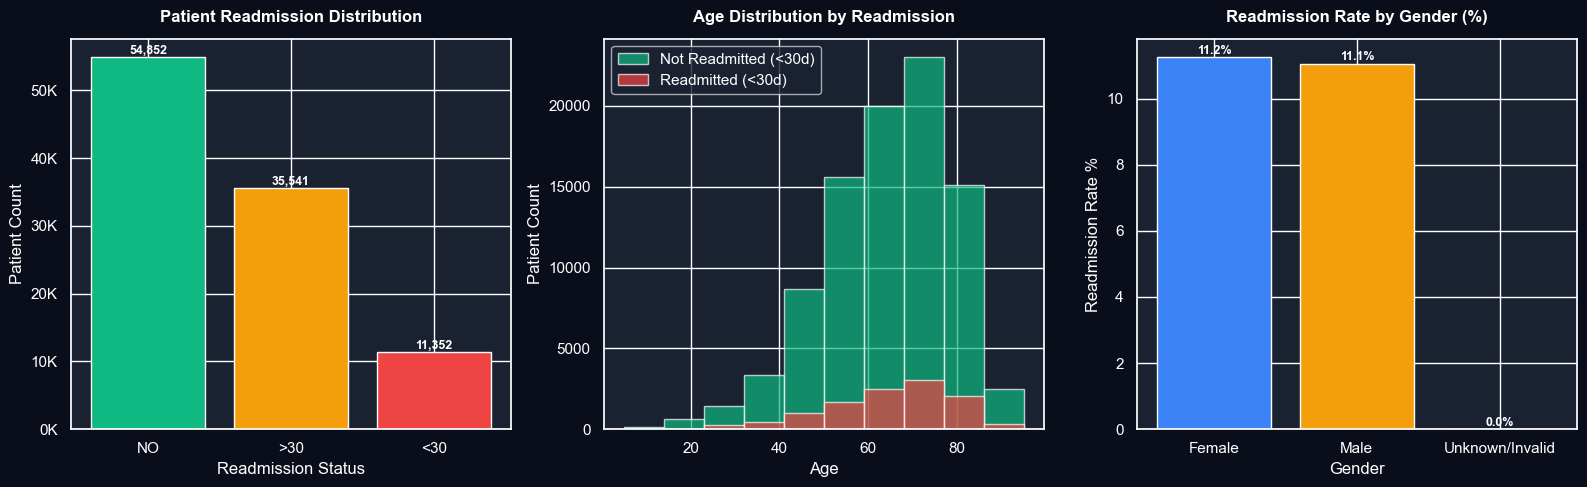

✅ Chart saved → screenshots/01_readmission_overview.png


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1a — Readmission distribution
colors = ['#10B981', '#EF4444']
readmit_counts = df['readmitted'].value_counts()
axes[0].bar(readmit_counts.index, readmit_counts.values, 
            color=['#10B981','#F59E0B','#EF4444'])
axes[0].set_title('Patient Readmission Distribution', fontweight='bold', pad=12)
axes[0].set_xlabel('Readmission Status')
axes[0].set_ylabel('Patient Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
for i, v in enumerate(readmit_counts.values):
    axes[0].text(i, v+500, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

# Chart 1b — Age distribution by readmission
df_high = df[df['readmitted_binary']==1]['age_numeric']
df_low  = df[df['readmitted_binary']==0]['age_numeric']
axes[1].hist(df_low,  bins=10, alpha=0.7, color='#10B981', label='Not Readmitted (<30d)')
axes[1].hist(df_high, bins=10, alpha=0.7, color='#EF4444', label='Readmitted (<30d)')
axes[1].set_title('Age Distribution by Readmission', fontweight='bold', pad=12)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Patient Count')
axes[1].legend()

# Chart 1c — Gender vs readmission
gender_readmit = df.groupby('gender')['readmitted_binary'].mean() * 100
axes[2].bar(gender_readmit.index, gender_readmit.values, 
            color=['#3B82F6','#F59E0B','#6B7280'])
axes[2].set_title('Readmission Rate by Gender (%)', fontweight='bold', pad=12)
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Readmission Rate %')
for i, v in enumerate(gender_readmit.values):
    axes[2].text(i, v+0.1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../screenshots/01_readmission_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/01_readmission_overview.png")

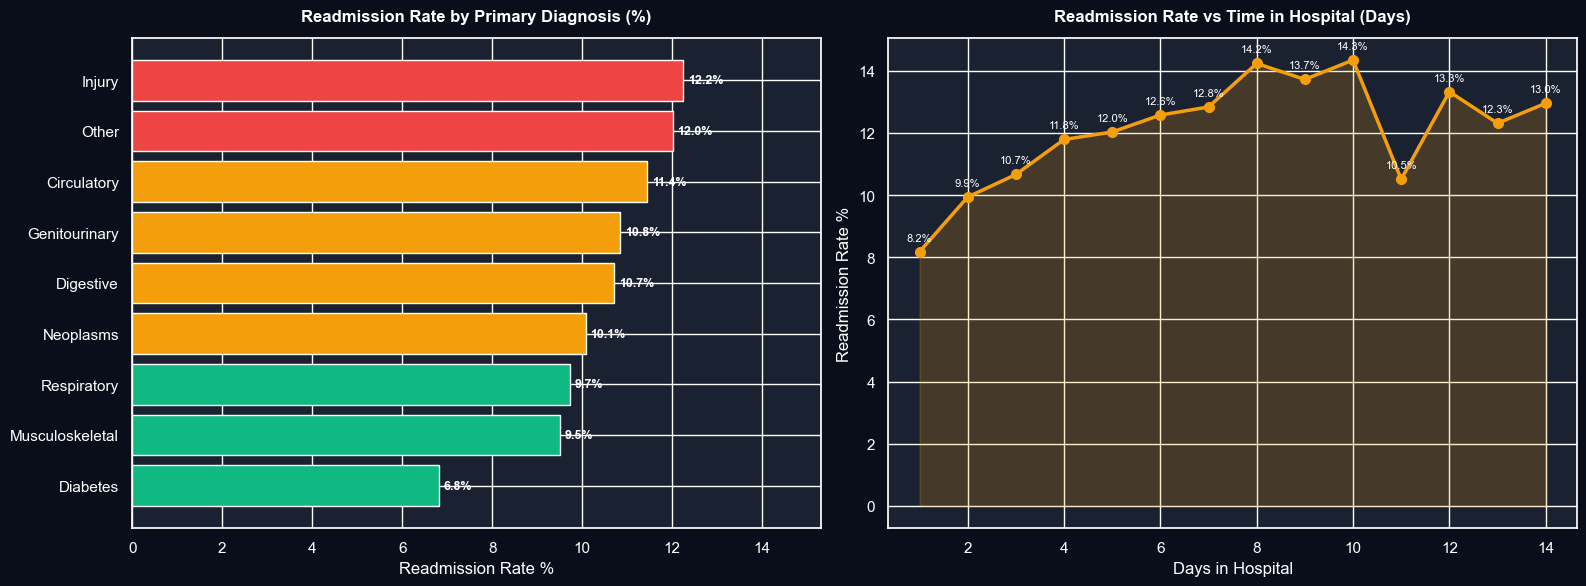

✅ Chart saved → screenshots/02_diagnosis_clinical.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 2a — Readmission rate by diagnosis category
diag_readmit = df.groupby('diag_1_category').agg(
    readmit_rate=('readmitted_binary', 'mean'),
    count=('readmitted_binary', 'count')
).reset_index()
diag_readmit['readmit_rate'] = diag_readmit['readmit_rate'] * 100
diag_readmit = diag_readmit.sort_values('readmit_rate', ascending=True)

colors = ['#EF4444' if r > 12 else '#F59E0B' if r > 10 
          else '#10B981' for r in diag_readmit['readmit_rate']]
axes[0].barh(diag_readmit['diag_1_category'], 
             diag_readmit['readmit_rate'], color=colors)
axes[0].set_title('Readmission Rate by Primary Diagnosis (%)', 
                  fontweight='bold', pad=12)
axes[0].set_xlabel('Readmission Rate %')
for i, v in enumerate(diag_readmit['readmit_rate']):
    axes[0].text(v+0.1, i, f'{v:.1f}%', va='center', 
                fontweight='bold', fontsize=9)
axes[0].set_xlim(0, diag_readmit['readmit_rate'].max() * 1.25)

# Chart 2b — Time in hospital vs readmission
time_readmit = df.groupby('time_in_hospital')['readmitted_binary'].mean() * 100
axes[1].plot(time_readmit.index, time_readmit.values, 
             color='#F59E0B', linewidth=2.5, marker='o', markersize=7)
axes[1].fill_between(time_readmit.index, time_readmit.values, 
                     alpha=0.2, color='#F59E0B')
axes[1].set_title('Readmission Rate vs Time in Hospital (Days)', 
                  fontweight='bold', pad=12)
axes[1].set_xlabel('Days in Hospital')
axes[1].set_ylabel('Readmission Rate %')
for x, y in zip(time_readmit.index, time_readmit.values):
    axes[1].annotate(f'{y:.1f}%', (x, y), 
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../screenshots/02_diagnosis_clinical.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/02_diagnosis_clinical.png")

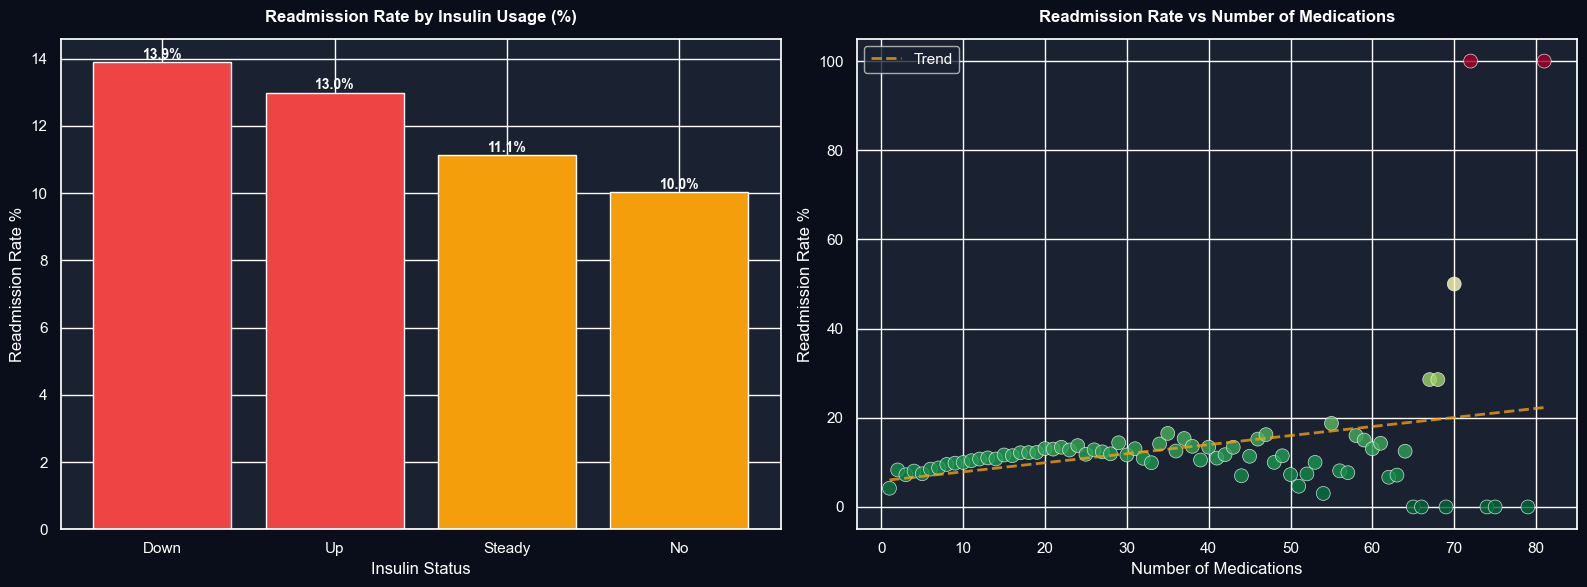

✅ Chart saved → screenshots/03_medications.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 3a — Insulin usage vs readmission
insulin_readmit = df.groupby('insulin')['readmitted_binary'].mean() * 100
insulin_readmit = insulin_readmit.sort_values(ascending=False)
colors = ['#EF4444' if v > 12 else '#F59E0B' 
          if v > 10 else '#10B981' for v in insulin_readmit.values]
axes[0].bar(insulin_readmit.index, insulin_readmit.values, color=colors)
axes[0].set_title('Readmission Rate by Insulin Usage (%)', 
                  fontweight='bold', pad=12)
axes[0].set_xlabel('Insulin Status')
axes[0].set_ylabel('Readmission Rate %')
for i, v in enumerate(insulin_readmit.values):
    axes[0].text(i, v+0.1, f'{v:.1f}%', ha='center', 
                fontweight='bold', fontsize=10)

# Chart 3b — Number of medications vs readmission
med_readmit = df.groupby('num_medications')['readmitted_binary'].mean() * 100
axes[1].scatter(med_readmit.index, med_readmit.values,
                c=med_readmit.values, cmap='RdYlGn_r',
                s=100, alpha=0.8, edgecolors='white', linewidth=0.5)
# Trend line
z = np.polyfit(med_readmit.index, med_readmit.values, 1)
p = np.poly1d(z)
axes[1].plot(med_readmit.index, p(med_readmit.index), 
             color='#F59E0B', linewidth=2, linestyle='--', 
             alpha=0.8, label='Trend')
axes[1].set_title('Readmission Rate vs Number of Medications', 
                  fontweight='bold', pad=12)
axes[1].set_xlabel('Number of Medications')
axes[1].set_ylabel('Readmission Rate %')
axes[1].legend()

plt.tight_layout()
plt.savefig('../screenshots/03_medications.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/03_medications.png")

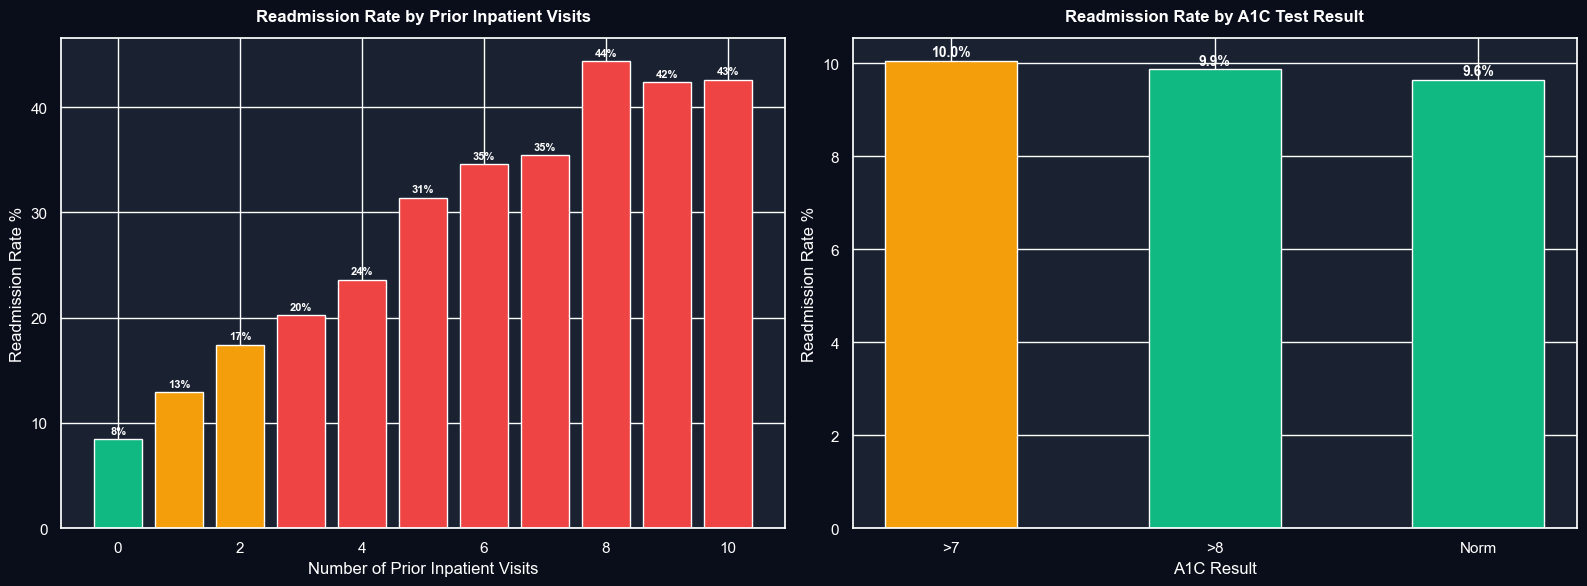

✅ Chart saved → screenshots/04_utilization.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 4a — Readmission by number of inpatient visits
inpatient_readmit = df.groupby('number_inpatient')['readmitted_binary'].agg(
    ['mean', 'count']).reset_index()
inpatient_readmit['mean'] = inpatient_readmit['mean'] * 100
inpatient_readmit = inpatient_readmit[inpatient_readmit['count'] > 50]

axes[0].bar(inpatient_readmit['number_inpatient'],
            inpatient_readmit['mean'],
            color=['#EF4444' if v > 20 else '#F59E0B' 
                   if v > 12 else '#10B981' 
                   for v in inpatient_readmit['mean']])
axes[0].set_title('Readmission Rate by Prior Inpatient Visits',
                  fontweight='bold', pad=12)
axes[0].set_xlabel('Number of Prior Inpatient Visits')
axes[0].set_ylabel('Readmission Rate %')
for i, row in inpatient_readmit.iterrows():
    axes[0].text(row['number_inpatient'], row['mean']+0.5,
                f'{row["mean"]:.0f}%', ha='center', fontsize=8,
                fontweight='bold')

# Chart 4b — A1C result vs readmission
a1c_readmit = df.groupby('A1Cresult')['readmitted_binary'].mean() * 100
a1c_readmit = a1c_readmit.sort_values(ascending=False)
colors = ['#EF4444' if v > 12 else '#F59E0B' 
          if v > 10 else '#10B981' for v in a1c_readmit.values]
axes[1].bar(a1c_readmit.index, a1c_readmit.values, color=colors, width=0.5)
axes[1].set_title('Readmission Rate by A1C Test Result',
                  fontweight='bold', pad=12)
axes[1].set_xlabel('A1C Result')
axes[1].set_ylabel('Readmission Rate %')
for i, v in enumerate(a1c_readmit.values):
    axes[1].text(i, v+0.1, f'{v:.1f}%', ha='center',
                fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../screenshots/04_utilization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/04_utilization.png")

In [6]:
print("=" * 60)
print("   MedIQ — EDA COMPLETE: KEY CLINICAL INSIGHTS")
print("=" * 60)
print(f"""
📊 DATASET
   Total patients     : {len(df):,}
   High-risk (<30d)   : {df['readmitted_binary'].sum():,} ({df['readmitted_binary'].mean()*100:.1f}%)
   Average age        : {df['age_numeric'].mean():.0f} years
   Avg time in hosp   : {df['time_in_hospital'].mean():.1f} days

🏥 KEY CLINICAL FINDINGS

1. STRONGEST PREDICTOR — Prior inpatient visits
   0 visits  → 9% readmission
   8+ visits → 44% readmission (5x higher risk)

2. DIAGNOSIS — Injury patients most at risk
   Injury     → 12.2% readmission rate
   Diabetes   → 6.8% (lowest — better managed)

3. MEDICATIONS — Insulin reduction = danger signal
   Insulin Down → 13.9% readmission (highest)
   No insulin   → 10.0% (lowest)

4. HOSPITAL STAY — Longer = higher risk
   1-3 days → ~9% readmission
   7-10 days → ~14% readmission

5. A1C TEST — Surprisingly weak predictor
   All A1C categories within 0.4% of each other

6. GENDER — No significant difference
   Female: 11.2% | Male: 11.0%

Next → 02_sql_analysis.ipynb
""")
print("=" * 60)

   MedIQ — EDA COMPLETE: KEY CLINICAL INSIGHTS

📊 DATASET
   Total patients     : 101,745
   High-risk (<30d)   : 11,352 (11.2%)
   Average age        : 66 years
   Avg time in hosp   : 4.4 days

🏥 KEY CLINICAL FINDINGS

1. STRONGEST PREDICTOR — Prior inpatient visits
   0 visits  → 9% readmission
   8+ visits → 44% readmission (5x higher risk)

2. DIAGNOSIS — Injury patients most at risk
   Injury     → 12.2% readmission rate
   Diabetes   → 6.8% (lowest — better managed)

3. MEDICATIONS — Insulin reduction = danger signal
   Insulin Down → 13.9% readmission (highest)
   No insulin   → 10.0% (lowest)

4. HOSPITAL STAY — Longer = higher risk
   1-3 days → ~9% readmission
   7-10 days → ~14% readmission

5. A1C TEST — Surprisingly weak predictor
   All A1C categories within 0.4% of each other

6. GENDER — No significant difference
   Female: 11.2% | Male: 11.0%

Next → 02_sql_analysis.ipynb

